Loading data...
Preprocessing data...
Handling outliers...
Splitting data...
Building model pipeline...
Training model...
Evaluating model...
Validation RMSE: 10.9200
Validation MAE: 6.8385
Validation R^2: 0.7440
Performing cross-validation...
Cross-validation RMSE: 10.9251 ± 0.0436
Analyzing feature importance...
Making predictions...
Submission file created: submission.csv
Done!


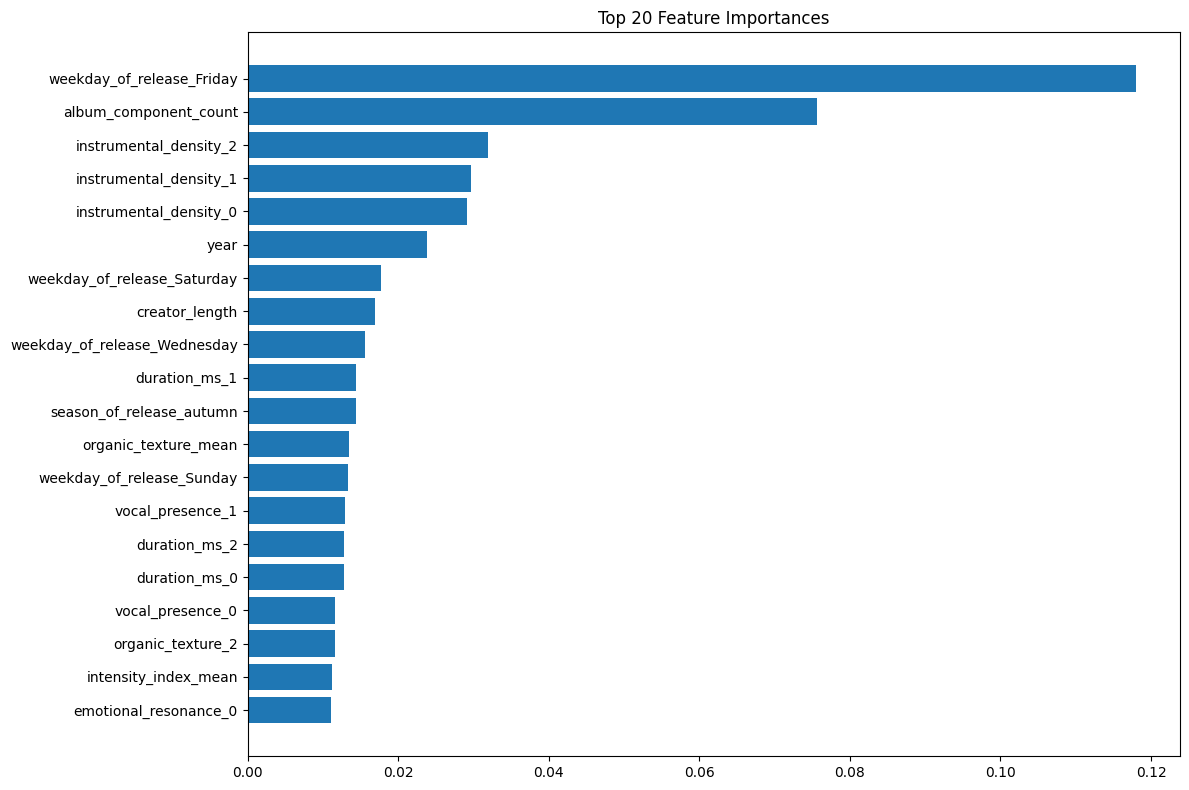

In [2]:
"""
Music Track Popularity Prediction Model
--------------------------------------
This script preprocesses music track data, trains an XGBoost regression model,
and generates predictions for track popularity.

Author: [Your Name]
Date: April 29, 2025
"""

# --- Import Statements ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# --- Constants and Configuration ---
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# --- Data Loading ---
def load_data(train_path='train.csv', test_path='test.csv'):
    """Load training and test datasets"""
    train_data = pd.read_csv(train_path)
    test_data = pd.read_csv(test_path)
    
    # Extract target variable from training data
    X_full = train_data.drop(['target'], axis=1)
    y_full = train_data['target']
    
    return X_full, y_full, test_data

# --- Data Preprocessing ---
def preprocess_data(df):
    """Preprocess the data by extracting features and transforming variables"""
    # Make a copy to avoid modifying the original dataframe
    data = df.copy()
    
    # Extract datetime features from publication_timestamp
    data['publication_timestamp'] = pd.to_datetime(data['publication_timestamp'])
    data['year'] = data['publication_timestamp'].dt.year
    data['month'] = data['publication_timestamp'].dt.month
    data['day'] = data['publication_timestamp'].dt.day
    data['day_of_year'] = data['publication_timestamp'].dt.dayofyear
    data['quarter'] = data['publication_timestamp'].dt.quarter
    
    # Create artist name length
    data['creator_length'] = data['creator_collective'].apply(lambda x: len(str(x)))
    
    # Process track_identifier (title) features
    data['track_identifier_length'] = data['track_identifier'].apply(lambda x: len(str(x)))
    data['track_identifier_word_count'] = data['track_identifier'].apply(lambda x: len(str(x).split()))
    
    # Calculate additional statistics for audio features across tracks
    audio_features = ['rhythmic_cohesion', 'intensity_index', 'organic_texture', 'beat_frequency']
    
    for feature in audio_features:
        # Get all columns related to this feature across tracks
        cols = [col for col in data.columns if feature in col]
        
        if len(cols) > 1:
            # Calculate mean across tracks
            data[f'{feature}_mean'] = data[cols].mean(axis=1)
            # Calculate standard deviation across tracks
            data[f'{feature}_std'] = data[cols].std(axis=1)
            # Calculate range across tracks
            data[f'{feature}_range'] = data[cols].max(axis=1) - data[cols].min(axis=1)
    
    # Calculate audio feature ratios and interactions
    # Energy to danceability ratio for all tracks
    for i in range(3):  # For tracks 0-2
        data[f'energy_dance_ratio_{i}'] = data[f'intensity_index_{i}'] / (data[f'rhythmic_cohesion_{i}'] + 0.001)
        data[f'dance_energy_product_{i}'] = data[f'intensity_index_{i}'] * data[f'rhythmic_cohesion_{i}']
    
    # Drop columns that shouldn't be used for modeling
    drop_columns = ['track_identifier', 'creator_collective', 'publication_timestamp', 
                   'composition_label_0', 'composition_label_1', 'composition_label_2']
    
    # Check if columns exist before dropping
    drop_columns = [col for col in drop_columns if col in data.columns]
    data = data.drop(drop_columns, axis=1)
    
    return data

def handle_outliers(df, columns):
    """Handle outliers in numeric columns using IQR method"""
    df_clean = df.copy()
    
    for col in columns:
        if col in df_clean.columns and df_clean[col].dtype in ['int64', 'float64']:
            Q1 = df_clean[col].quantile(0.25)
            Q3 = df_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Cap the outliers instead of removing them
            df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)
            
    return df_clean

# --- Model Building ---
def build_preprocessor(X_data):
    """Build a preprocessing pipeline for feature transformation"""
    # Identify numeric and categorical columns
    numeric_features = X_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = X_data.select_dtypes(include=['object']).columns.tolist()
    
    # Create preprocessing pipelines
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    
    # Combine preprocessing steps
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])
    
    return preprocessor, numeric_features, categorical_features

def build_model_pipeline(preprocessor):
    """Create a model pipeline with preprocessor and XGBoost model"""
    # Define the XGBoost model
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED
    )
    
    # Create the full pipeline
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', xgb_model)
    ])
    
    return model_pipeline

def train_with_early_stopping(X_train, y_train, X_val, y_val, preprocessor, model_pipeline):
    """Train model with early stopping"""
    # Process training and validation data for XGBoost
    preprocessed_train = preprocessor.fit_transform(X_train)
    preprocessed_val = preprocessor.transform(X_val)
    
    # Create a separate XGBoost model with early stopping for this training
    early_stop_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED,
        early_stopping_rounds=10
    )
    
    # Train with early stopping
    early_stop_model.fit(
        preprocessed_train, y_train,
        eval_set=[(preprocessed_val, y_val)],
        verbose=False
    )
    
    # Get the best number of estimators determined by early stopping
    best_iteration = early_stop_model.best_iteration
    
    # Update our pipeline model with the best number of estimators
    model_pipeline.named_steps['model'].n_estimators = best_iteration if best_iteration > 0 else model_pipeline.named_steps['model'].n_estimators
    
    # Train the pipeline normally
    model_pipeline.fit(X_train, y_train)
    
    return model_pipeline

# --- Evaluation ---
def evaluate_model(model, X_val, y_val):
    """Evaluate model performance on validation set"""
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    
    print(f"Validation RMSE: {rmse:.4f}")
    print(f"Validation MAE: {mae:.4f}")
    print(f"Validation R^2: {r2:.4f}")
    
    return rmse, mae, r2

def perform_cross_validation(model, X, y, cv=5):
    """Perform cross-validation to assess model performance"""
    cv_scores = cross_val_score(model, X, y, 
                               cv=cv, scoring='neg_root_mean_squared_error')
    print(f"Cross-validation RMSE: {-cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    return -cv_scores.mean()

# --- Feature Importance Analysis ---
def analyze_feature_importance(preprocessor, X_processed, y_full, numeric_features, categorical_features, top_n=20):
    """Analyze and plot feature importance"""
    # Train the model directly on preprocessed data to get feature importance
    preprocessed_train = preprocessor.fit_transform(X_processed)
    
    final_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED
    )
    
    # Train the final model
    final_model.fit(preprocessed_train, y_full)
    
    # Get feature names
    feature_names = numeric_features.copy()
    if categorical_features:
        ohe_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
        feature_names.extend(ohe_feature_names)
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    sorted_idx = np.argsort(final_model.feature_importances_)[-top_n:]  # Top N features
    plt.barh(range(len(sorted_idx)), final_model.feature_importances_[sorted_idx])
    plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
    plt.title(f'Top {top_n} Feature Importances')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    
    return final_model, feature_names

# --- Prediction ---
def make_predictions(model, test_data, output_file='submission4.csv'):
    """Make predictions on test data and create submission file"""
    # Make predictions
    test_predictions = model.predict(test_data)
    
    # Prepare submission file
    submission = pd.DataFrame({
        'id': test_data['id'] if 'id' in test_data.columns else range(len(test_data)),
        'target': test_predictions
    })
    
    # Ensure predictions are within the valid range (0-100)
    submission['target'] = submission['target'].clip(0, 100)
    
    # Save submission file
    submission.to_csv(output_file, index=False)
    print(f"Submission file created: {output_file}")
    
    return submission

# --- Main Execution ---
def main():
    # Load data
    print("Loading data...")
    X_full, y_full, test_data = load_data()
    
    # Preprocess data
    print("Preprocessing data...")
    X_processed = preprocess_data(X_full)
    test_processed = preprocess_data(test_data)
    
    # Handle outliers in numeric columns of training data
    print("Handling outliers...")
    numeric_cols = X_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
    X_processed = handle_outliers(X_processed, numeric_cols)
    
    # Split data for training and validation
    print("Splitting data...")
    X_train, X_val, y_train, y_val = train_test_split(
        X_processed, y_full, test_size=0.2, random_state=RANDOM_SEED
    )
    
    # Build preprocessor and model pipeline
    print("Building model pipeline...")
    preprocessor, numeric_features, categorical_features = build_preprocessor(X_processed)
    model_pipeline = build_model_pipeline(preprocessor)
    
    # Train model with early stopping
    print("Training model...")
    model_pipeline = train_with_early_stopping(
        X_train, y_train, X_val, y_val, preprocessor, model_pipeline
    )
    
    # Evaluate model
    print("Evaluating model...")
    rmse, mae, r2 = evaluate_model(model_pipeline, X_val, y_val)
    
    # Perform cross-validation
    print("Performing cross-validation...")
    cv_rmse = perform_cross_validation(model_pipeline, X_processed, y_full)
    
    # Analyze feature importance
    print("Analyzing feature importance...")
    final_model, feature_names = analyze_feature_importance(
        preprocessor, X_processed, y_full, numeric_features, categorical_features
    )
    
    # Make predictions on test set
    print("Making predictions...")
    submission = make_predictions(model_pipeline, test_processed, output_file='submission.csv')
    
    print("Done!")
    return model_pipeline, submission

if __name__ == "__main__":
    main()